In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
 # Load CSV file into DataFrame
df = pd.read_csv("../Data/credit_risk_dataset.csv") 
df.head()  # Show first 5 rows

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [27]:
# Print dataset shape (rows, columns)
print(f'Rows X Columns: {df.shape}')

Rows X Columns: (32581, 12)


In [28]:
# Show summary of dataset (columns, data types, missing values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Some data types here are incorrect, need to change.

In [29]:
# Count missing values in each column
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Columns "person_emp_length" and "loan_int_rate" have missing values ​​that need to be handled.

In [30]:
print(f"Duplicate values: {df.duplicated().sum()}")

Duplicate values: 165


In [31]:
# Show statistical summary of numerical columns
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Age
- Average age is 27.73 years
- Minimum is 20, but maximum is 144, which looks like an outlier

Income 
- Mean income is 66,074
- Maximum value (6,000,000) is very high → possible extreme outlier

Employment Length 
- Average work experience is 4.79 years
- Maximum value is 123, which is unrealistic → needs outlier handling

The other columns are fine. They need to be adjusted as needed.

In [32]:
# Count of each class in loan_status (0 = paid, 1 = default)
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In target column, classes are unbalanced. These need to be handled.

In [33]:
sel_col = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in sel_col:
    print(df[col].value_counts())
    print("-----------------------")

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
-----------------------
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
-----------------------
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
-----------------------
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
-----------------------


In [34]:
#duplicate values remove
df = df.drop_duplicates()

In [35]:
print('Age > 80:')
df[df['person_age'] > 80]

Age > 80:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32416,94,24000,RENT,1.0,MEDICAL,C,6500,NaN,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24


It's unnatural to look over 80. These need to be thrown away.

In [36]:
# Age over 80, romoving these rows
df = df[df['person_age'] < 80]

In [37]:
print("Employee Who work >40 year")
df[df['person_emp_length'] > 40]

Employee Who work >40 year


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25


It is also unusual to see more than 40 years of work experience. These need to be removed.

In [38]:
#Employee length over 40, romoving these rows
df = df[df['person_emp_length'] < 40]

In [39]:
#Filling missing values ​​with the median
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [40]:
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Don't have any missing value

In [41]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


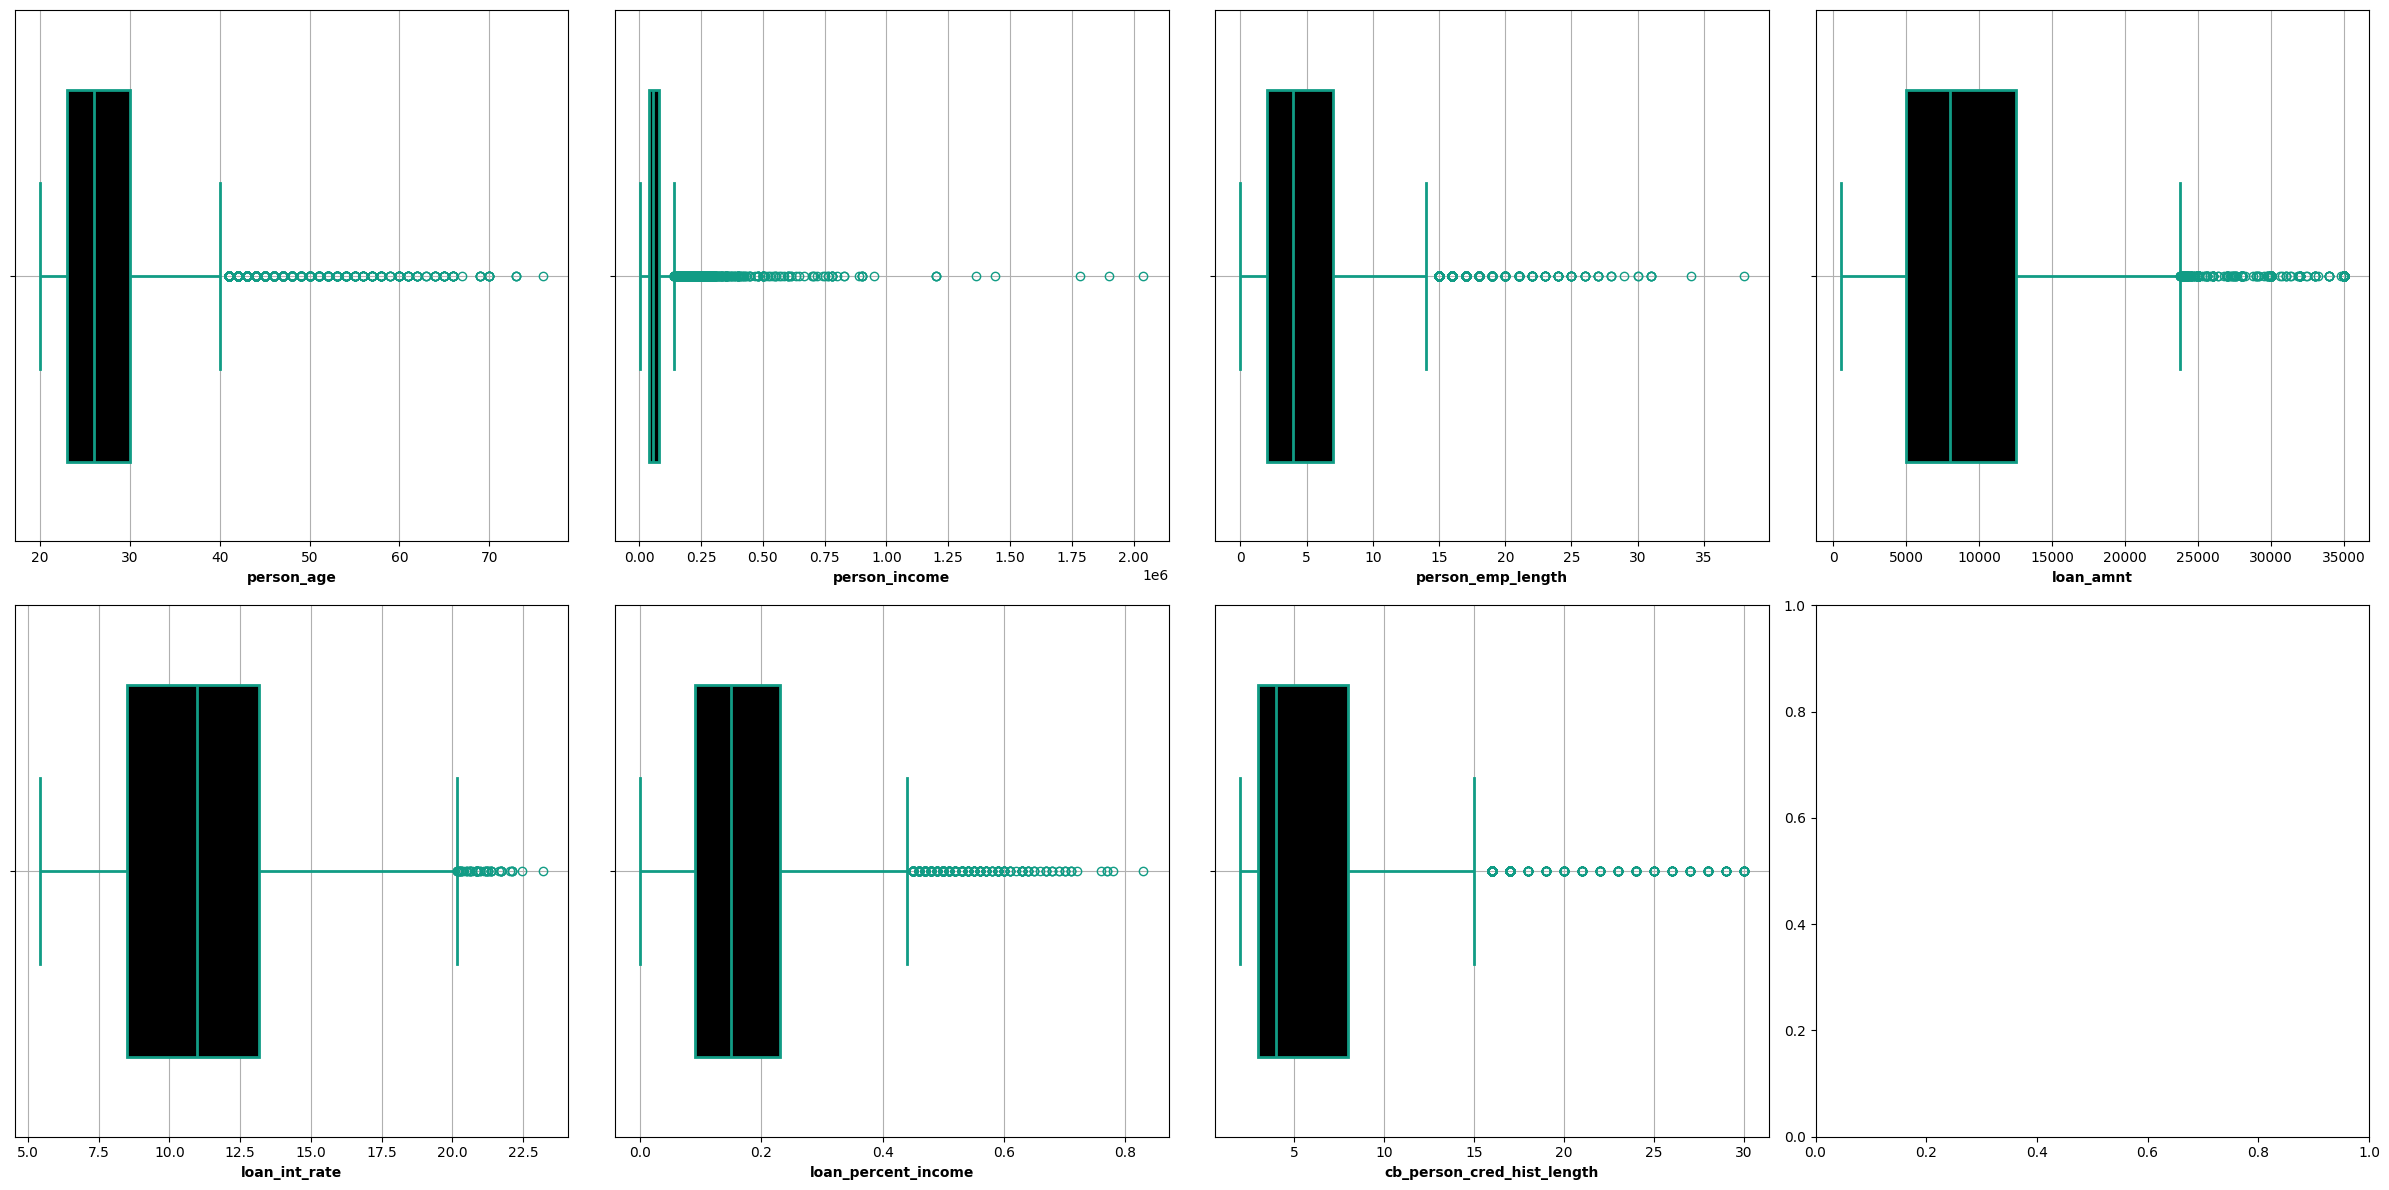

In [42]:
outlier_col = [
    'person_age', 'person_income', 
    'person_emp_length', 'loan_amnt', 
    'loan_int_rate', 'loan_percent_income', 
    'cb_person_cred_hist_length'
] 

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
for ax, col in zip(axes.flatten(), outlier_col):
    sns.boxplot(
        x = df[col],
        ax =ax,
        color= "#000000",
        linewidth=2,
        linecolor="#119C85", 
        width=0.7
    )
    ax.set_xlabel(col, weight='bold')
    ax.grid(True)
plt.tight_layout()

There are some extreme outliers in "person_income", "person_emp_length" & "loan_percent_income" column. We will remove these manually.
And we will take care of the rest later.

In [43]:
#Remove some extreme outlier 
df = df[df['person_income'] <= 1000000]
df = df[df['person_emp_length'] < 32]
df = df[df['loan_percent_income'] < 0.8]

In [44]:
df.to_csv("../Data/Cleaned_dataset.csv", index=False)